In [2]:
# Instalar y/o cargar todos los paquetes de una vez
if (!require("pacman")) {
  install.packages("pacman")
}
# Cargar paquetes necesarios para el análisis
pacman::p_load(
  factoextra,
  readr,
  FactoMineR,
  GGally,
  ggplot2,
  missMDA,
  corrplot,
  NbClust,
  cluster,
  fpc,
  dendextend,
  readxl,
  visdat,
  Hmisc,      # Load before tidyverse
  psych,      # Load before tidyverse
  tidyverse   # Loads dplyr last, ensuring its functions take precedence
)

Loading required package: pacman


### Cargar los datos

In [3]:
data_num_imputed <- read_csv(
  "C:/Users/user/CO2-emsiones-tipo-combustible/data/processed/data_num_imputed.csv"
)

str(data_num_imputed)

Rows: 23 Columns: 18
── Column specification ─────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl (18): Año, Total, Asfaltos, Avtur, Bagazo de caña, Carbón mineral, Coque, Diesel, Fuel oi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
spc_tbl_ [23 × 18] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ Año                    : num [1:23] 2000 2001 2002 2003 2004 ...
 $ Total                  : num [1:23] 22509 22065 24103 22033 21745 ...
 $ Asfaltos               : num [1:23] 65.5 77.9 72.8 24.2 30.9 ...
 $ Avtur                  : num [1:23] 478 536 247 523 666 ...
 $ Bagazo de caña         : num [1:23] 887 896 956 931 1029 ...
 $ Carbón mineral         : num [1:23] 254 410 1313 1882 2624 ...
 $ Coque                  : num [1:23] 218 319 426 281 862 ...
 $ Diesel                 : num [1:23] 6186 4719 4592 3284 3292 ...
 $ Fuel oil           

### correlación

In [4]:
correlaciones <- cor(data_num_imputed[, -c(1, 2)])
cor_res <- rcorr(as.matrix(data_num_imputed[, -c(1, 2)]))  
cor_mat <- cor_res$r
p_mat <- cor_res$P

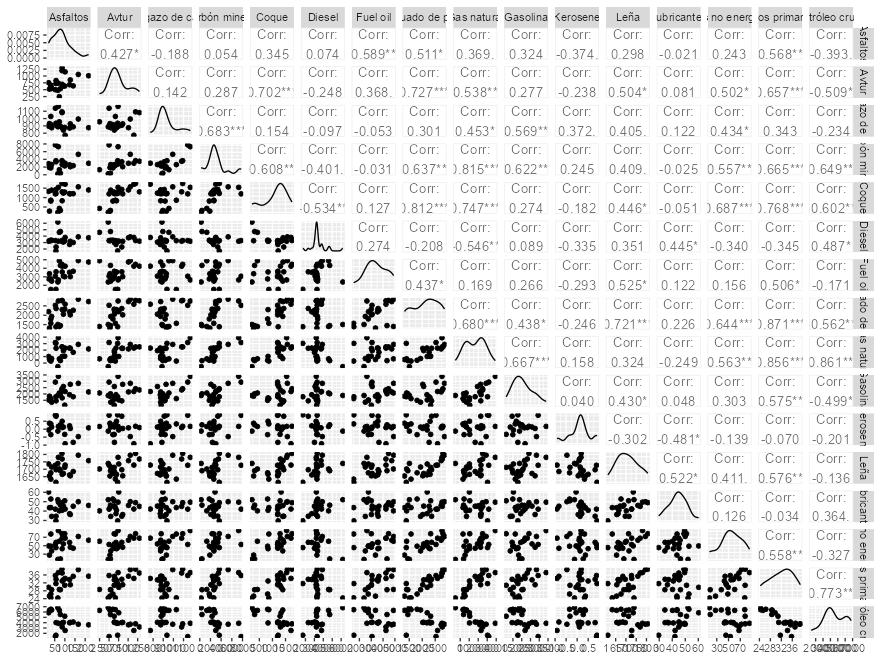

In [5]:
ggpairs(data_num_imputed[, -c(1, 2)])

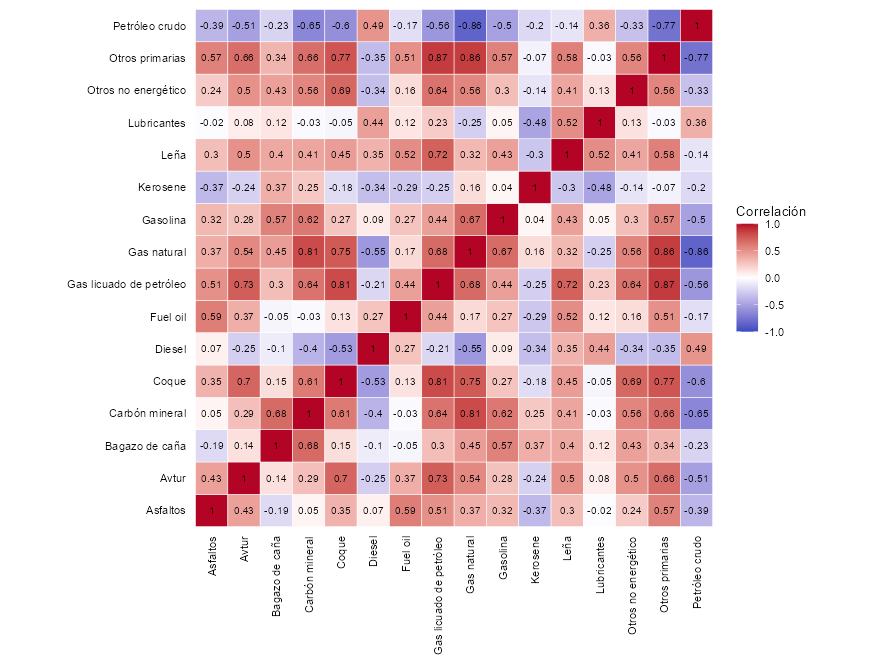

In [16]:
library(ggcorrplot)
library(ggplot2)

grafico_cor <- ggcorrplot(
  correlaciones,
  method = "square",
  type = "full",
  lab = TRUE,
  lab_col = "black",
  lab_size = 3,
  digits = 2,
  colors = c("#3B4CC0", "white", "#B40426"),
  outline.color = "white",
  show.diag = TRUE,
  legend.title = "Correlación"
) +
  theme_minimal() +
  theme(
    axis.title = element_blank(),
    axis.text.x = element_text(
      angle = 90,
      hjust = 1,
      vjust = 0.5,
      size = 9,
      color = "black"
    ),
    axis.text.y = element_text(
      size = 9,
      color = "black"
    ),
    panel.grid = element_blank(),
    plot.margin = margin(5, 5, 5, 5)
  )

grafico_cor

In [17]:
ggsave(
  filename = "C:/Users/user/CO2-emsiones-tipo-combustible/results/figures/matriz_correlacion.tiff",
  plot = grafico_cor,
  width = 12,
  height = 10,
  units = "in",
  dpi = 400,
  compression = "lzw",
  bg = "white"
)

### Diagnóstico adecuado para decidir si se puede aplicar PCA

In [18]:
det_cor <- det(cor_mat)
eig_vals <- eigen(cor_mat)$values
var_explained <- eig_vals / sum(eig_vals)
cum_var <- cumsum(var_explained)
n_eig_gt1 <- sum(eig_vals > 1)

In [19]:
corr_analysis <- list(
  correlation = cor_mat,
  p_values = p_mat,
  determinant = det_cor,
  eigenvalues = eig_vals,
  variance_explained = var_explained,
  cumulative_variance = cum_var,
  n_eigen_gt1 = n_eig_gt1
)

corr_analysis

$correlation
                           Asfaltos       Avtur Bagazo de caña Carbón mineral       Coque
Asfaltos                 1.00000000  0.42735097    -0.18767424     0.05447673  0.34504300
Avtur                    0.42735097  1.00000000     0.14227141     0.28652272  0.70153890
Bagazo de caña          -0.18767424  0.14227141     1.00000000     0.68293583  0.15385658
Carbón mineral           0.05447673  0.28652272     0.68293583     1.00000000  0.60795764
Coque                    0.34504300  0.70153890     0.15385658     0.60795764  1.00000000
Diesel                   0.07392170 -0.24795141    -0.09651380    -0.40081995 -0.53373136
Fuel oil                 0.58894907  0.36757536    -0.05305984    -0.03110839  0.12740934
Gas licuado de petróleo  0.51080130  0.72737379     0.30075809     0.63723488  0.81168145
Gas natural              0.36927694  0.53808950     0.45292689     0.81468568  0.74705388
Gasolina                 0.32419242  0.27744679     0.56880429     0.62232152  0.273674

Se reporta la matriz de correlación completa y sus valores p (rcorr, paquete Hmisc) para trazabilidad total. Varias correlaciones son fuertes y coherentes con relaciones esperadas entre fuentes de energía sustitutas/complementarias (p. ej., Gas natural–Carbón mineral r = 0.81; Gas licuado de petróleo–Avtur r = 0.73), lo que anticipa una estructura factorial no trivial.

### Medida de adecuación muestral de Kaiser-Meyer-Olkin (KMO)

In [20]:
library(psych)
KMO(data_num_imputed[, -c(1, 2)])

Kaiser-Meyer-Olkin factor adequacy
Call: KMO(r = data_num_imputed[, -c(1, 2)])
Overall MSA =  0.54
MSA for each item = 
               Asfaltos                   Avtur          Bagazo de caña          Carbón mineral 
                   0.73                    0.58                    0.46                    0.68 
                  Coque                  Diesel                Fuel oil Gas licuado de petróleo 
                   0.61                    0.28                    0.42                    0.82 
            Gas natural                Gasolina                Kerosene                    Leña 
                   0.63                    0.40                    0.49                    0.38 
            Lubricantes     Otros no energético         Otros primarias          Petróleo crudo 
                   0.28                    0.54                    0.73                    0.51 

### Prueba de esfericidad de Bartlett

In [21]:
cor_for_bartlett <- cor(data_num_imputed[, -c(1, 2)])
bartlett_res <- cortest.bartlett(cor_for_bartlett, n = nrow(data_num_imputed))
bartlett_res

$chisq
[1] 337.7413

$p.value
[1] 1.344912e-22

$df
[1] 120


El KMO global inicial es 0.54 (“miserable” según el criterio de Kaiser), con siete variables por debajo del umbral de adecuación individual (MSA < 0.5): Diesel (0.28), Lubricantes (0.28), Leña (0.38), Gasolina (0.40), Fuel oil (0.42), Kerosene (0.49) y Bagazo de caña (0.46). La prueba de esfericidad de Bartlett es altamente significativa (χ² = 337.74, gl = 120, p < .001), confirmando que existen correlaciones no triviales, pero la adecuación muestral global es insuficiente mientras esas siete variables permanezcan en el modelo.

#### Eliminar variables de baja MSA (MSA < 0,5)

In [22]:
kmo_result <- KMO(data_num_imputed[, -c(1, 2)])
msa_values <- kmo_result$MSAi
low_msa_vars <- names(msa_values[msa_values < 0.5])
cat("Eliminar variables de baja MSA:", paste(low_msa_vars, collapse = ", "), "\n")

Eliminar variables de baja MSA: Bagazo de caña, Diesel, Fuel oil, Gasolina, Kerosene, Leña, Lubricantes 


#### Crear conjunto de datos filtrado (mantener Año y Total, eliminar variables de combustible MSA bajas)

In [23]:
cols_to_keep <- !colnames(data_num_imputed) %in% low_msa_vars
data_filtered <- data_num_imputed[, cols_to_keep]

#### Volver a calcular los diagnósticos en los datos filtrados

In [24]:
correlaciones_filtered <- cor(data_filtered[, -c(1, 2)])
cor_res_filtered <- rcorr(as.matrix(data_filtered[, -c(1, 2)]))  
cor_mat_filtered <- cor_res_filtered$r
p_mat_filtered <- cor_res_filtered$P

In [25]:
det_cor_filtered <- det(cor_mat_filtered)
eig_vals_filtered <- eigen(cor_mat_filtered)$values
var_explained_filtered <- eig_vals_filtered / sum(eig_vals_filtered)
cum_var_filtered <- cumsum(var_explained_filtered)
n_eig_gt1_filtered <- sum(eig_vals_filtered > 1)

#### KMO y Bartlett en datos filtrados

In [27]:
kmo_filtered <- KMO(data_filtered[, -c(1, 2)])
bartlett_filtered <- cortest.bartlett(
  cor(data_filtered[, -c(1, 2)]),
  n = nrow(data_filtered)
)

cat("\n=== Filtered Data Diagnostics ===\n")


=== Filtered Data Diagnostics ===


In [30]:
KMO(data_filtered[, -c(1, 2)])

Kaiser-Meyer-Olkin factor adequacy
Call: KMO(r = data_filtered[, -c(1, 2)])
Overall MSA =  0.73
MSA for each item = 
               Asfaltos                   Avtur          Carbón mineral                   Coque 
                   0.60                    0.72                    0.58                    0.85 
Gas licuado de petróleo             Gas natural     Otros no energético         Otros primarias 
                   0.65                    0.70                    0.88                    0.79 
         Petróleo crudo 
                   0.87 

In [31]:
cat("Bartlett p-value:", bartlett_filtered$p.value, "\n")

Bartlett p-value: 1.44025e-21 


In [49]:
bartlett_filtered$chisq


[1] 182.9136

In [50]:
bartlett_filtered$df


[1] 36

In [51]:
bartlett_filtered$p.value

[1] 1.44025e-21

In [32]:
cat("Determinant:", det_cor_filtered, "\n")

Determinant: 4.238821e-05 


In [33]:
cat("Eigenvalues > 1:", n_eig_gt1_filtered, "\n")

Eigenvalues > 1: 2 


In [34]:
cat(
  "Cumulative variance (first 4 PCs):",
  cum_var_filtered[1:min(4, length(cum_var_filtered))],
  "\n"
)

Cumulative variance (first 4 PCs): 0.6462416 0.7689343 0.8635608 0.9188465 


Tras remover las siete variables de baja adecuación, el KMO global mejora de 0.54 a 0.73 (“meritorio”), la prueba de Bartlett se mantiene altamente significativa (p ≈ 1.4 × 10⁻²¹) y el determinante de la matriz de correlación (4.24 × 10⁻⁵) confirma ausencia de colinealidad extrema. Dos autovalores superan 1, y los primeros cuatro componentes explican el 91.9 % de la varianza — el conjunto de nueve combustibles retenidos (Asfaltos, Avtur, Carbón mineral, Coque, Gas licuado de petróleo, Gas natural, Otros no energético, Otros primarias y Petróleo crudo) es adecuado para un análisis de componentes principales.

## Análisis de Componentes Principales (PCA)

In [ ]:
pca <- prcomp(data_filtered[, -c(1, 2)], scale. = TRUE)
set.seed(123)

Importance of components:
                          PC1    PC2     PC3     PC4     PC5     PC6     PC7     PC8     PC9
Standard deviation     2.4117 1.0508 0.92284 0.70539 0.54874 0.44440 0.33473 0.30850 0.15672
Proportion of Variance 0.6462 0.1227 0.09463 0.05529 0.03346 0.02194 0.01245 0.01057 0.00273
Cumulative Proportion  0.6462 0.7689 0.86356 0.91885 0.95230 0.97425 0.98670 0.99727 1.00000

Los dos primeros componentes explican el 76.89 % de la varianza total (PC1 = 64.62 %, PC2 = 12.27 %), una proporción alta que respalda representar la estructura multivariante del conjunto en un plano bidimensional.

### estabilidad mediante bootstrap

Dado que la data es relativamente pequeña, se procede a realizar una pureba de estabilidad mediente boostrap.

Como no se tiene otra muestra, el bootstrap crea muchas "muestras nuevas" a partir de la original.

In [56]:
data_pca <- data_filtered[, -c(1, 2)]

In [57]:
dim(data_pca)

[1] 23  9

In [58]:
names(data_pca)

[1] "Asfaltos"                "Avtur"                   "Carbón mineral"         
[4] "Coque"                   "Gas licuado de petróleo" "Gas natural"            
[7] "Otros no energético"     "Otros primarias"         "Petróleo crudo"         

In [59]:
set.seed(123)

B <- 1000
n <- nrow(data_pca)
p <- ncol(data_pca)

In [64]:
n


[1] 23

In [65]:
p

[1] 9

In [66]:
cargas_boot <- array(
  NA_real_,
  dim = c(p, 2, B),
  dimnames = list(
    variable = colnames(data_pca),
    componente = c("PC1", "PC2"),
    replica = paste0("B", 1:B)
  )
)

varianza_boot <- matrix(
  NA_real_,
  nrow = B,
  ncol = 2,
  dimnames = list(
    replica = paste0("B", 1:B),
    componente = c("PC1", "PC2")
  )
)

In [67]:
dim(cargas_boot)


[1]    9    2 1000

In [68]:
dim(varianza_boot)

[1] 1000    2

In [69]:
# Cargas de referencia del PCA original
cargas_ref <- pca$rotation[, 1:2, drop = FALSE]

# Registrar cuáles réplicas se calcularon correctamente
replicas_validas <- logical(B)

for (b in seq_len(B)) {

  # 1. Seleccionar 23 filas con reemplazo
  indices <- sample(
    seq_len(n),
    size = n,
    replace = TRUE
  )

  datos_b <- data_pca[indices, , drop = FALSE]

  # 2. Comprobar que ninguna variable quede constante
  desvios <- vapply(
    datos_b,
    sd,
    numeric(1),
    na.rm = TRUE
  )

  if (any(!is.finite(desvios) | desvios == 0)) {
    next
  }

  # 3. Calcular el PCA de la réplica
  pca_b <- tryCatch(
    prcomp(
      datos_b,
      center = TRUE,
      scale. = TRUE
    ),
    error = function(e) NULL
  )

  if (is.null(pca_b)) {
    next
  }

  cargas_b <- pca_b$rotation

  varianza_b <- 100 * (
    pca_b$sdev^2 / sum(pca_b$sdev^2)
  )

  componentes_usados <- integer(0)

  # 4. Identificar y alinear PC1 y PC2
  for (j in 1:2) {

    similitud <- as.numeric(
      crossprod(cargas_ref[, j], cargas_b)
    )

    if (length(componentes_usados) > 0) {
      similitud[componentes_usados] <- NA_real_
    }

    componente_b <- which.max(abs(similitud))

    # Corregir posibles cambios de signo
    if (similitud[componente_b] < 0) {
      cargas_b[, componente_b] <-
        -cargas_b[, componente_b]
    }

    cargas_boot[, j, b] <-
      cargas_b[, componente_b]

    varianza_boot[b, j] <-
      varianza_b[componente_b]

    componentes_usados <- c(
      componentes_usados,
      componente_b
    )
  }

  replicas_validas[b] <- TRUE
}

In [70]:
sum(replicas_validas)

[1] 1000

In [71]:
varianza_original <- 100 * (
  pca$sdev^2 / sum(pca$sdev^2)
)

resumen_varianza <- data.frame(
  Componente = c("PC1", "PC2"),

  Varianza_original = varianza_original[1:2],

  Media_bootstrap = colMeans(
    varianza_boot,
    na.rm = TRUE
  ),

  IC_95_inferior = apply(
    varianza_boot,
    2,
    quantile,
    probs = 0.025,
    na.rm = TRUE
  ),

  IC_95_superior = apply(
    varianza_boot,
    2,
    quantile,
    probs = 0.975,
    na.rm = TRUE
  )
)

In [72]:
resumen_varianza

    Componente Varianza_original Media_bootstrap IC_95_inferior IC_95_superior
PC1        PC1          64.62416        65.39851      52.827316       76.57654
PC2        PC2          12.26927        13.11435       5.399611       19.45689

In [73]:
resumen_cargas <- do.call(
  rbind,
  lapply(1:2, function(j) {

    data.frame(
      Variable = rownames(cargas_ref),
      Componente = paste0("PC", j),

      Carga_original = cargas_ref[, j],

      Media_bootstrap = apply(
        cargas_boot[, j, , drop = FALSE],
        1,
        mean,
        na.rm = TRUE
      ),

      IC_95_inferior = apply(
        cargas_boot[, j, , drop = FALSE],
        1,
        quantile,
        probs = 0.025,
        na.rm = TRUE
      ),

      IC_95_superior = apply(
        cargas_boot[, j, , drop = FALSE],
        1,
        quantile,
        probs = 0.975,
        na.rm = TRUE
      )
    )
  })
)

In [74]:
resumen_cargas[, 3:6] <- round(
  resumen_cargas[, 3:6],
  3
)

resumen_cargas

                                        Variable Componente Carga_original Media_bootstrap
Asfaltos                                Asfaltos        PC1          0.213           0.210
Avtur                                      Avtur        PC1          0.308           0.307
Carbón mineral                    Carbón mineral        PC1          0.312           0.316
Coque                                      Coque        PC1          0.366           0.361
Gas licuado de petróleo  Gas licuado de petróleo        PC1          0.374           0.371
Gas natural                          Gas natural        PC1          0.376           0.375
Otros no energético          Otros no energético        PC1          0.293           0.285
Otros primarias                  Otros primarias        PC1          0.390           0.390
Petróleo crudo                    Petróleo crudo        PC1         -0.331          -0.332
Asfaltos1                               Asfaltos        PC2          0.683           0.588

In [75]:
library(dplyr)

resumen_cargas <- resumen_cargas |>
  mutate(
    Estabilidad = case_when(
      IC_95_inferior > 0 ~ "Estable positiva",
      IC_95_superior < 0 ~ "Estable negativa",
      TRUE ~ "Inestable: incluye cero"
    )
  )

rownames(resumen_cargas) <- NULL

In [76]:
resumen_cargas |>
  as_tibble() |>
  print(n = Inf, width = Inf)

# A tibble: 18 × 7
   Variable                Componente Carga_original Media_bootstrap IC_95_inferior
   <chr>                   <chr>               <dbl>           <dbl>          <dbl>
 1 Asfaltos                PC1                 0.213           0.21           0.114
 2 Avtur                   PC1                 0.308           0.307          0.234
 3 Carbón mineral          PC1                 0.312           0.316          0.264
 4 Coque                   PC1                 0.366           0.361          0.309
 5 Gas licuado de petróleo PC1                 0.374           0.371          0.326
 6 Gas natural             PC1                 0.376           0.375          0.352
 7 Otros no energético     PC1                 0.293           0.285          0.134
 8 Otros primarias         PC1                 0.39            0.39           0.362
 9 Petróleo crudo          PC1                -0.331          -0.332         -0.374
10 Asfaltos                PC2                 0.683     

El primer componente principal presenta una estructura estable y reproducible. El segundo componente es menos estable y está definido principalmente por el contraste entre Asfaltos, con carga positiva, y Carbón mineral, con carga negativa. Las cargas de las demás variables en PC2 deben interpretarse con cautela.


La estabilidad de la solución del PCA fue evaluada mediante 1,000 réplicas bootstrap, obtenidas por remuestreo con reemplazo de las observaciones. El PC1 mostró una estructura estable, ya que todas las cargas conservaron su dirección y sus intervalos bootstrap del 95 % no incluyeron cero. En contraste, el PC2 presentó menor estabilidad: únicamente Asfaltos y Carbón mineral mantuvieron cargas consistentemente positivas y negativas, respectivamente. Estos resultados indican que la interpretación del PC1 es robusta, mientras que el PC2 debe considerarse un eje secundario y ser interpretado con cautela debido al reducido tamaño muestral.

Warning message:
In geom_bar(stat = "identity", fill = barfill, color = barcolor,  :
  Ignoring empty aesthetic: `width`.


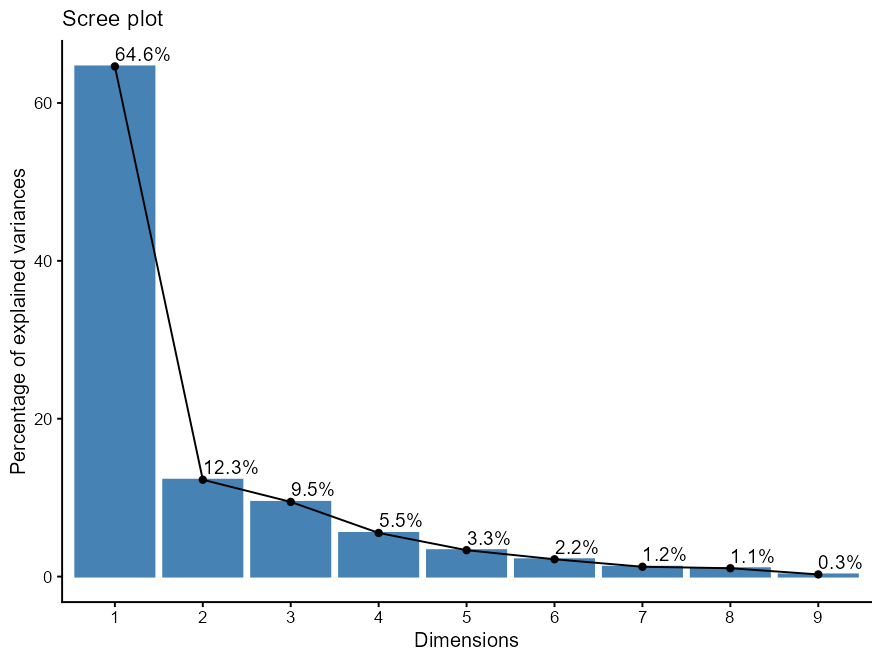

In [36]:
fviz_eig(
  pca,
  addlabels = TRUE,   
  labelsize = 6       
) +
  theme_classic(base_size = 16) +   
  theme(
    axis.text = element_text(size = 14),
    axis.title = element_text(size = 16),
    plot.title = element_text(size = 18)
  )

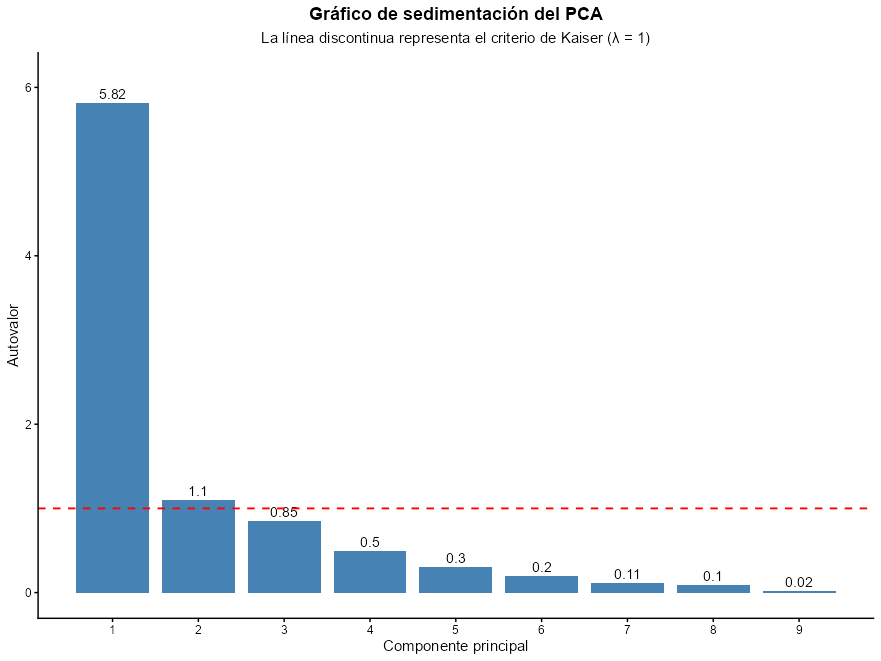

In [105]:
# Extraer autovalores del PCA
autovalores <- pca$sdev^2

datos_scree <- data.frame(
  Componente = seq_along(autovalores),
  Autovalor = autovalores
)

figura_sedimentacion <- ggplot(
  datos_scree,
  aes(x = Componente, y = Autovalor)
) +
  geom_col(
    fill = "steelblue",
    width = 0.85
  ) +
  geom_text(
    aes(label = round(Autovalor, 2)),
    vjust = -0.4,
    size = 4
  ) +
  geom_hline(
    yintercept = 1,
    linetype = "dashed",
    color = "red",
    linewidth = 0.7
  ) +
  scale_x_continuous(
    breaks = datos_scree$Componente
  ) +
  expand_limits(
    y = max(datos_scree$Autovalor) * 1.05
  ) +
  labs(
    title = "Gráfico de sedimentación del PCA",
    subtitle = "La línea discontinua representa el criterio de Kaiser (λ = 1)",
    x = "Componente principal",
    y = "Autovalor"
  ) +
  theme_classic(base_size = 12) +
  theme(
    plot.title = element_text(
      face = "bold",
      hjust = 0.5
    ),
    plot.subtitle = element_text(
      hjust = 0.5
    )
  )

figura_sedimentacion

In [106]:
ggsave(
  filename = paste0(
    "C:/Users/user/CO2-emsiones-tipo-combustible/",
    "results/figures/",
    "Grafico_sedimentacion_PCA.tiff"
  ),
  plot = figura_sedimentacion,
  width = 7,
  height = 5,
  units = "in",
  dpi = 400,
  compression = "lzw",
  bg = "white"
)

In [38]:
data_filtered_df <- as.data.frame(data_filtered)

years <- data_filtered_df$Año
rownames(data_filtered_df) <- years  

Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <]8;;https://github.com/kassambara/ggpubr/issueshttps://github.com/kassambara/ggpubr/issues]8;;>.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 


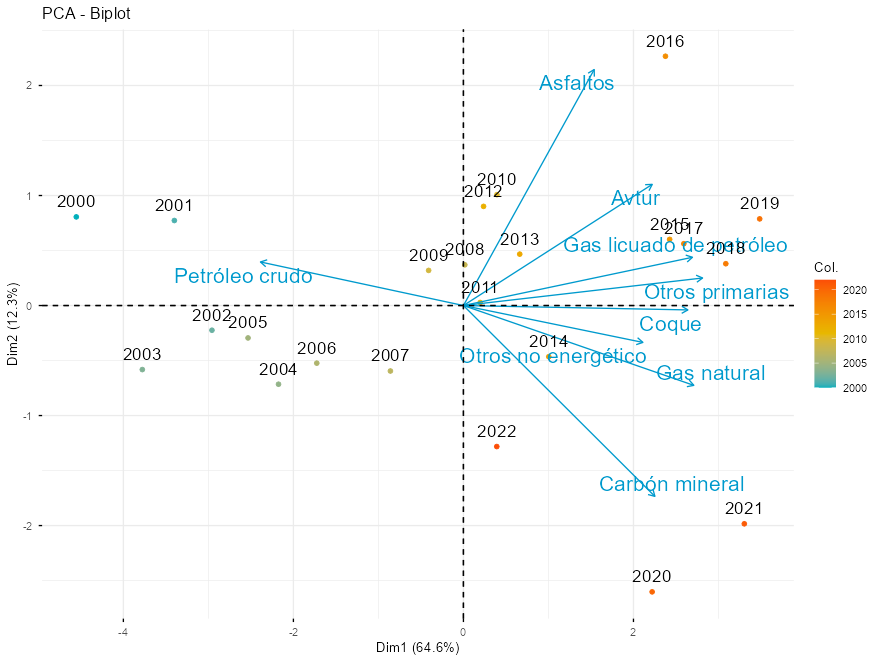

In [39]:
fviz_pca_biplot(
  pca,
  geom.ind = "point", # mostrar puntos
  labelsize = 6, # tamaño de letras
  label = "all", #  Mostrar etiquetas por defecto
  col.ind = years, # color por año
  gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"), # paleta para años
  col.var = "#009ACD", # color de vectores de variables
  repel = TRUE # evitar solapamiento
) +
  geom_text(
    aes(label = years), # añadir texto de los años
    vjust = -0.8,
    size = 5,
    color = "black"
  )

In [40]:
var_pca <- get_pca_var(pca)

print(var_pca$coord)

                             Dim.1       Dim.2       Dim.3        Dim.4         Dim.5
Asfaltos                 0.5143800  0.71731055  0.27584894 -0.358033550  0.0493349277
Avtur                    0.7426119  0.36828397 -0.23682093  0.458085314  0.0605913449
Carbón mineral           0.7530223 -0.58001948  0.06797534 -0.149063771 -0.1613422804
Coque                    0.8829600 -0.01332899 -0.24571279  0.123498053 -0.0007977746
Gas licuado de petróleo  0.9008170  0.14662523 -0.17793819 -0.037701217 -0.3365056798
Gas natural              0.9062481 -0.24262811  0.24062549 -0.005282805  0.1353084746
Otros no energético      0.7059424 -0.11210782 -0.55173531 -0.299653779  0.2841806779
Otros primarias          0.9406712  0.08368498  0.15122759 -0.041231970 -0.1335512440
Petróleo crudo          -0.7984239  0.13239244 -0.48746499 -0.170665814 -0.1970702621
                              Dim.6       Dim.7        Dim.8         Dim.9
Asfaltos                -0.01699759 -0.11662188 -0.004248453  0.0

In [41]:
print(var_pca$contrib)

                            Dim.1       Dim.2      Dim.3        Dim.4        Dim.5      Dim.6
Asfaltos                 4.549155 46.59649355  8.9348510 25.762784568  0.808312990  0.1462966
Avtur                    9.481702 12.28299911  6.5854405 42.173348973  1.219247155 16.5850404
Carbón mineral           9.749408 30.46659771  0.5425596  4.465700152  8.645038809  5.6036382
Coque                   13.404316  0.01608916  7.0892481  3.065247676  0.000211364 71.5625702
Gas licuado de petróleo 13.951975  1.94695624  3.7177740  0.285664379 37.605846026  1.3297515
Gas natural             14.120718  5.33115145  6.7987320  0.005608859  6.080237753  0.1963039
Otros no energético      8.568426  1.13817920 35.7442530 18.046162785 26.820054575  4.1775547
Otros primarias         15.213820  0.63421116  2.6853861  0.341675256  5.923336989  0.2365249
Petróleo crudo          10.960481  1.58732242 27.9017557  5.853807352 12.897714338  0.1623196
                            Dim.7       Dim.8        Dim.9
A

In [42]:
print(var_pca$cos2)

                            Dim.1       Dim.2       Dim.3        Dim.4        Dim.5        Dim.6
Asfaltos                0.2645868 0.514534427 0.076092639 1.281880e-01 2.433935e-03 0.0002889181
Avtur                   0.5514724 0.135633079 0.056084153 2.098422e-01 3.671311e-03 0.0327534575
Carbón mineral          0.5670426 0.336422597 0.004620647 2.222001e-02 2.603133e-02 0.0110665105
Coque                   0.7796184 0.000177662 0.060374773 1.525177e-02 6.364443e-07 0.1413274576
Gas licuado de petróleo 0.8114712 0.021498957 0.031661998 1.421382e-03 1.132361e-01 0.0026260991
Gas natural             0.8212857 0.058868399 0.057900625 2.790803e-05 1.830838e-02 0.0003876766
Otros no energético     0.4983546 0.012568164 0.304411853 8.979239e-02 8.075866e-02 0.0082501675
Otros primarias         0.8848624 0.007003177 0.022869785 1.700075e-03 1.783593e-02 0.0004671081
Petróleo crudo          0.6374807 0.017527757 0.237622119 2.912682e-02 3.883669e-02 0.0003205617
                              

In [43]:
ind_pca <- get_pca_ind(pca)

print(ind_pca$coord)

         Dim.1       Dim.2       Dim.3      Dim.4       Dim.5       Dim.6       Dim.7
1  -4.55364549  0.80571285  0.42650413  0.1695748 -0.56401848  0.32994645 -0.22143735
2  -3.40031408  0.77275699  1.17267905  0.3236235 -0.17406740  0.28595493  0.23217423
3  -2.95804207 -0.22446883 -0.11892057 -1.4989819  0.64388715  0.16878085  0.61787321
4  -3.77712136 -0.58216718  0.34514121  0.3943390 -0.08158873  0.58225395 -0.28654493
5  -2.17507874 -0.71509616 -1.90241343 -0.3531356  0.93181150  0.40997451 -0.43816817
6  -2.53357306 -0.29455903 -0.93022140  0.1621404 -0.14274774  0.02960960 -0.10056191
7  -1.72506407 -0.52369996 -0.65637892  0.3308965 -0.80851997 -1.11820790 -0.27531269
8  -0.85892966 -0.59509075 -1.09649499  0.7391761 -0.63166268 -0.41974842 -0.04609993
9   0.01622657  0.36998801 -1.19546692 -0.9445254  0.30495551 -0.29807151  0.21740509
10 -0.40928059  0.31930200  0.60393003  0.1051063 -0.54707625  0.38399822  0.38310931
11  0.39400283  1.00766192  0.91311620 -0.5144245 -0.3

In [44]:
print(ind_pca$cos2)

          Dim.1       Dim.2        Dim.3       Dim.4        Dim.5        Dim.6        Dim.7
1  0.9384391380 0.029379761 8.232546e-03 0.001301398 1.439708e-02 0.0049269096 0.0022191641
2  0.8347756284 0.043113926 9.928646e-02 0.007561569 2.187593e-03 0.0059037351 0.0038918824
3  0.7335664604 0.004224184 1.185618e-03 0.188375118 3.475764e-02 0.0023882352 0.0320058607
4  0.9245421347 0.021963435 7.719665e-03 0.010077303 4.313851e-04 0.0219699826 0.0053209636
5  0.4563507080 0.049326200 3.491070e-01 0.012029065 8.375387e-02 0.0162129660 0.0185195490
6  0.8618586416 0.011649676 1.161828e-01 0.003529812 2.735947e-03 0.0001177157 0.0013578013
7  0.5125213322 0.047235288 7.420117e-02 0.018857578 1.125856e-01 0.2153508537 0.0130543111
8  0.2157652124 0.103569676 3.516248e-01 0.159794575 1.166908e-01 0.0515281266 0.0006215366
9  0.0000892237 0.046387603 4.842858e-01 0.302310987 3.151371e-02 0.0301070056 0.0160164416
10 0.1137009548 0.069203029 2.475683e-01 0.007498581 2.031503e-01 0.1000875909 0

In [45]:
tabla_var_pca <- data.frame(
  Variable = rownames(var_pca$contrib),
  Contrib_PC1 = var_pca$contrib[, 1],
  Contrib_PC2 = var_pca$contrib[, 2],
  Cos2_PC1 = var_pca$cos2[, 1],
  Cos2_PC2 = var_pca$cos2[, 2]
) |>
  arrange(desc(Contrib_PC1))

tabla_var_pca

                                       Variable Contrib_PC1 Contrib_PC2  Cos2_PC1    Cos2_PC2
Otros primarias                 Otros primarias   15.213820  0.63421116 0.8848624 0.007003177
Gas natural                         Gas natural   14.120718  5.33115145 0.8212857 0.058868399
Gas licuado de petróleo Gas licuado de petróleo   13.951975  1.94695624 0.8114712 0.021498957
Coque                                     Coque   13.404316  0.01608916 0.7796184 0.000177662
Petróleo crudo                   Petróleo crudo   10.960481  1.58732242 0.6374807 0.017527757
Carbón mineral                   Carbón mineral    9.749408 30.46659771 0.5670426 0.336422597
Avtur                                     Avtur    9.481702 12.28299911 0.5514724 0.135633079
Otros no energético         Otros no energético    8.568426  1.13817920 0.4983546 0.012568164
Asfaltos                               Asfaltos    4.549155 46.59649355 0.2645868 0.514534427

Las variables que más contribuyen al PC1 son Otros primarias (15.2 %), Gas natural (14.1 %), Gas licuado de petróleo (14.0 %) y Coque (13.4 %), todas con carga positiva, mientras que Petróleo crudo es la única variable con carga negativa en PC1 (−0.798). Esto convierte al PC1 en un eje de “diversificación energética”: valores altos indican mayor peso relativo de fuentes distintas al petróleo crudo, valores bajos indican mayor dependencia del petróleo crudo. El PC2 está dominado por Asfaltos (46.6 % de contribución) y Carbón mineral (30.5 %), un eje secundario de mucha menor importancia relativa (12.3 % de varianza).

In [46]:
library(dplyr)
library(tidyr)
library(tibble)
library(knitr)

# ---------------------------------------------------------
# 1. Autovalores y varianza explicada
# ---------------------------------------------------------

autovalores <- pca$sdev^2

tabla_varianza <- tibble(
  Componente = colnames(pca$rotation),
  Autovalor = autovalores,
  `Varianza explicada (%)` =
    autovalores / sum(autovalores) * 100,
  `Varianza acumulada (%)` =
    cumsum(autovalores / sum(autovalores) * 100)
)

# Componentes retenidos mediante el criterio de Kaiser
componentes_retenidos <- tabla_varianza |>
  filter(Autovalor > 1) |>
  pull(Componente)

# ---------------------------------------------------------
# 2. Correlaciones variable-componente
# ---------------------------------------------------------

# Equivale a get_pca_var(pca)$coord
cargas_correlacionales <- sweep(
  pca$rotation,
  MARGIN = 2,
  STATS = pca$sdev,
  FUN = "*"
)

# ---------------------------------------------------------
# 3. Seleccionar las principales cargas
# ---------------------------------------------------------

principales_cargas <- as.data.frame(
  cargas_correlacionales[
    ,
    componentes_retenidos,
    drop = FALSE
  ]
) |>
  rownames_to_column("Variable") |>
  pivot_longer(
    cols = -Variable,
    names_to = "Componente",
    values_to = "Carga"
  ) |>
  group_by(Componente) |>
  arrange(desc(abs(Carga)), .by_group = TRUE) |>
  slice_head(n = 5) |>
  summarise(
    `Principales cargas` = paste(
      sprintf("%s (%+.3f)", Variable, Carga),
      collapse = "; "
    ),
    .groups = "drop"
  )

# ---------------------------------------------------------
# 4. Unir resultados
# ---------------------------------------------------------

tabla_pca <- tabla_varianza |>
  filter(Componente %in% componentes_retenidos) |>
  left_join(principales_cargas, by = "Componente") |>
  mutate(
    Autovalor = round(Autovalor, 3),
    `Varianza explicada (%)` =
      round(`Varianza explicada (%)`, 2),
    `Varianza acumulada (%)` =
      round(`Varianza acumulada (%)`, 2)
  )

knitr::kable(
  tabla_pca,
  caption = paste(
    "Autovalores, varianza explicada y principales",
    "correlaciones variable-componente del PCA."
  ),
  align = c("l", "r", "r", "r", "l")
)



Table: Autovalores, varianza explicada y principales correlaciones variable-componente del PCA.

|Componente | Autovalor| Varianza explicada (%)| Varianza acumulada (%)|Principales cargas                                                                                                        |
|:----------|---------:|----------------------:|----------------------:|:-------------------------------------------------------------------------------------------------------------------------|
|PC1        |     5.816|                  64.62|                  64.62|Otros primarias (+0.941); Gas natural (+0.906); Gas licuado de petróleo (+0.901); Coque (+0.883); Petróleo crudo (-0.798) |
|PC2        |     1.104|                  12.27|                  76.89|Asfaltos (+0.717); Carbón mineral (-0.580); Avtur (+0.368); Gas natural (-0.243); Gas licuado de petróleo (+0.147)        |

In [47]:
tabla_cargas <- as.data.frame(
  cargas_correlacionales[
    ,
    componentes_retenidos,
    drop = FALSE
  ]
) |>
  rownames_to_column("Variable") |>
  mutate(
    across(
      -Variable,
      ~ round(.x, 3)
    )
  )

knitr::kable(
  tabla_cargas,
  caption = paste(
    "Correlaciones entre las variables originales",
    "y los componentes principales retenidos."
  ),
  align = c("l", "r", "r")
)



Table: Correlaciones entre las variables originales y los componentes principales retenidos.

|Variable                |    PC1|    PC2|
|:-----------------------|------:|------:|
|Asfaltos                |  0.514|  0.717|
|Avtur                   |  0.743|  0.368|
|Carbón mineral          |  0.753| -0.580|
|Coque                   |  0.883| -0.013|
|Gas licuado de petróleo |  0.901|  0.147|
|Gas natural             |  0.906| -0.243|
|Otros no energético     |  0.706| -0.112|
|Otros primarias         |  0.941|  0.084|
|Petróleo crudo          | -0.798|  0.132|

In [52]:
str(data_filtered)

tibble [23 × 11] (S3: tbl_df/tbl/data.frame)
 $ Año                    : num [1:23] 2000 2001 2002 2003 2004 ...
 $ Total                  : num [1:23] 22509 22065 24103 22033 21745 ...
 $ Asfaltos               : num [1:23] 65.5 77.9 72.8 24.2 30.9 ...
 $ Avtur                  : num [1:23] 478 536 247 523 666 ...
 $ Carbón mineral         : num [1:23] 254 410 1313 1882 2624 ...
 $ Coque                  : num [1:23] 218 319 426 281 862 ...
 $ Gas licuado de petróleo: num [1:23] 1506 1448 1400 1317 1569 ...
 $ Gas natural            : num [1:23] -545 371 653 537 309 ...
 $ Otros no energético    : num [1:23] 17.7 18.9 60.5 27.9 77.6 ...
 $ Otros primarias        : num [1:23] 24.3 28.5 28.7 25.3 24.4 ...
 $ Petróleo crudo         : num [1:23] 6811 5532 6308 6319 6440 ...


## Análisis de conglomerados (k-means y jerárquico)

In [77]:
X_cluster <- scale(data_filtered_df[, -c(1, 2)])
rownames(X_cluster) <- years

Nota metodológica: las nueve variables retenidas se estandarizaron (z-score) antes de calcular distancias y ejecutar el clustering. Esto es necesario porque las variables originales difieren en magnitud (p. ej., Petróleo crudo en miles vs. Otros primarias en decenas); sin estandarizar, la distancia euclidiana quedaría dominada por las variables de mayor escala.

Warning message:
`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <]8;;https://github.com/kassambara/factoextra/issueshttps://github.com/kassambara/factoextra/issues]8;;>.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 


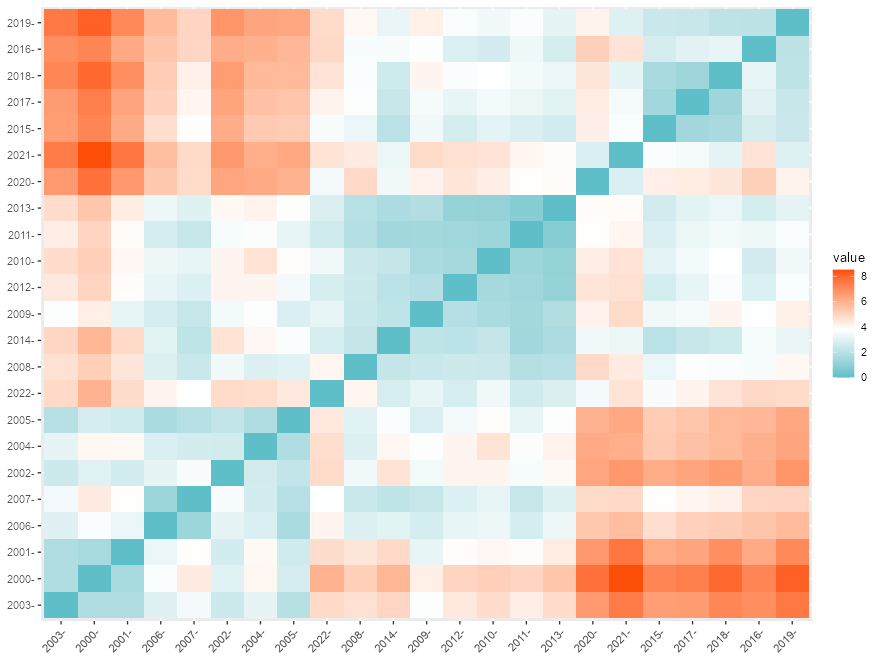

In [78]:
m.distancia <- get_dist(X_cluster, method = "euclidean")
fviz_dist(
  m.distancia,
  gradient = list(low = "#00AFBB", mid = "white", high = "#FC4E07")
)

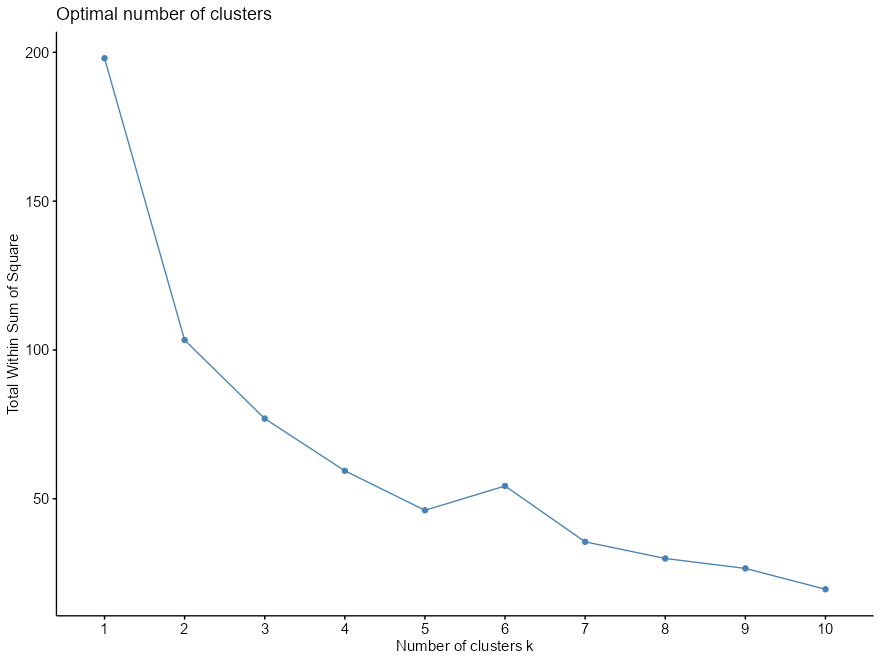

In [79]:
fviz_nbclust(X_cluster, kmeans, method = "wss")

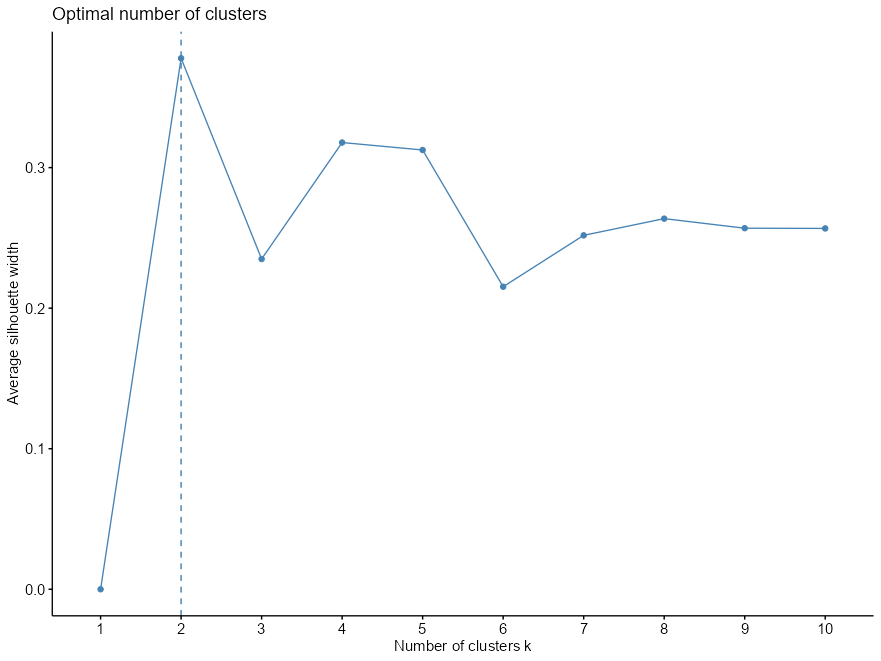

In [80]:
fviz_nbclust(X_cluster, kmeans, method = "silhouette")

Clustering k = 1,2,..., K.max (= 10): .. done
Bootstrapping, b = 1,2,..., B (= 100)  [one "." per sample]:
.................................................. 50 
.................................................. 100 


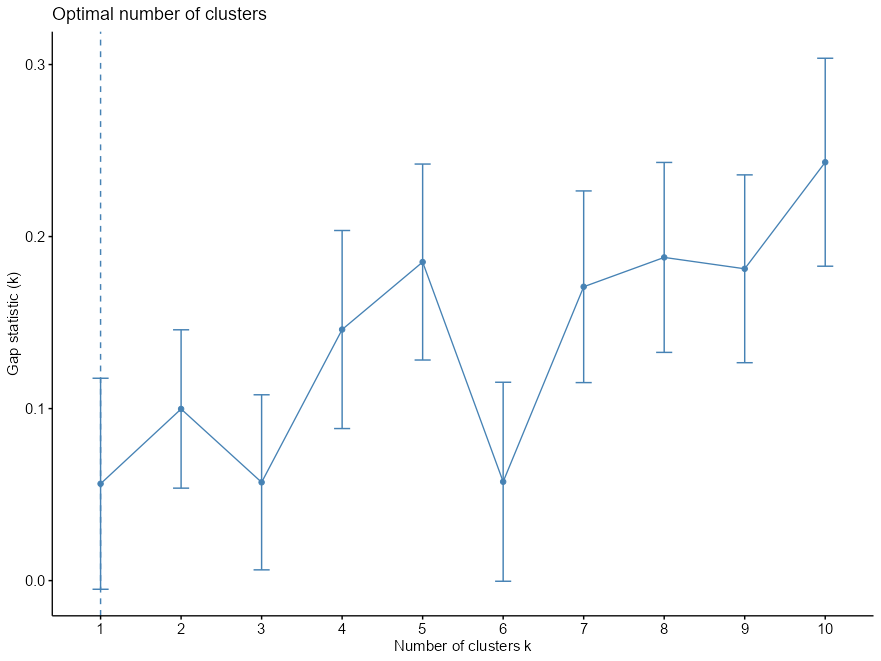

In [81]:
fviz_nbclust(X_cluster, kmeans, method = "gap_stat")

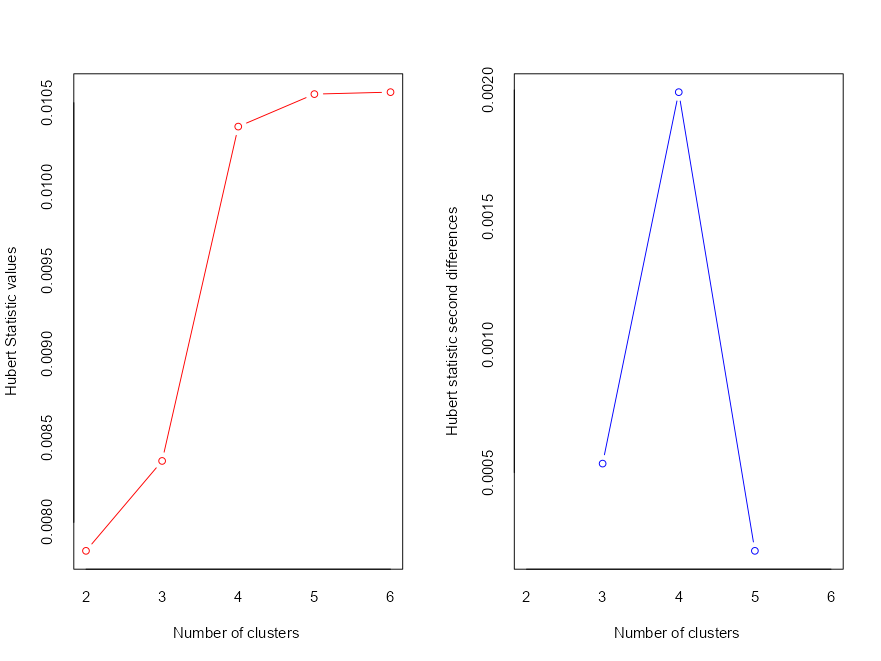

*** : The Hubert index is a graphical method of determining the number of clusters.
                In the plot of Hubert index, we seek a significant knee that corresponds to a 
                significant increase of the value of the measure i.e the significant peak in Hubert
                index second differences plot. 
 


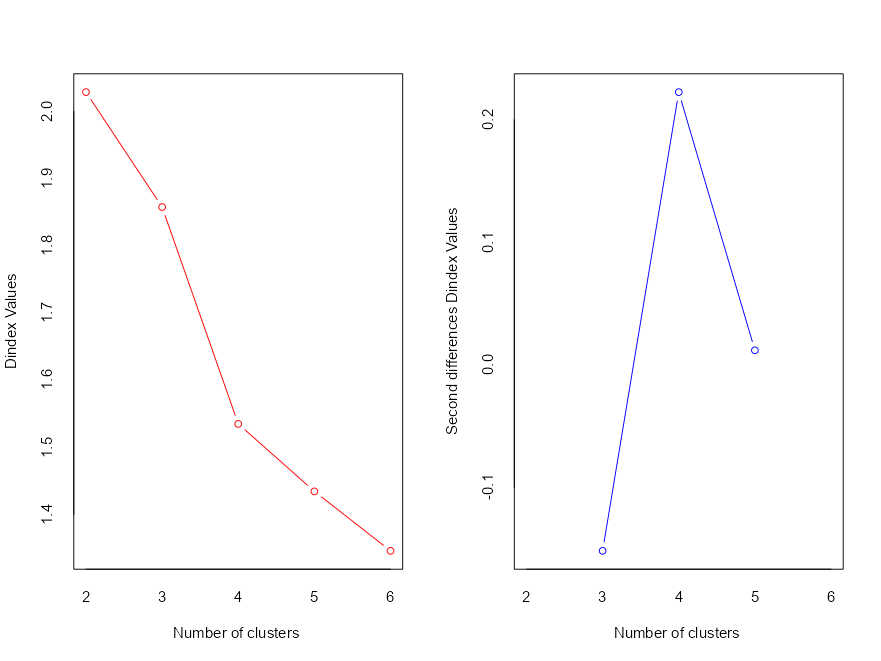

*** : The D index is a graphical method of determining the number of clusters. 
                In the plot of D index, we seek a significant knee (the significant peak in Dindex
                second differences plot) that corresponds to a significant increase of the value of
                the measure. 
 
******************************************************************* 
* Among all indices:                                                
* 13 proposed 2 as the best number of clusters 
* 2 proposed 3 as the best number of clusters 
* 5 proposed 4 as the best number of clusters 
* 1 proposed 5 as the best number of clusters 
* 3 proposed 6 as the best number of clusters 

                   ***** Conclusion *****                            
 
* According to the majority rule, the best number of clusters is  2 
 
 
******************************************************************* 


In [82]:
resumclust <- NbClust(
  X_cluster,
  distance = "euclidean",
  min.nc = 2,
  max.nc = 6,
  method = "kmeans",
  index = "all"
)

De 24 índices de validación con resultado válido, 13 favorecen k = 2 por regla de mayoría, frente a 5 que favorecen k = 4, 2 que favorecen k = 3, 3 que favorecen k = 6 y 1 que favorece k = 5. La conclusión de NbClust es clara para k = 2, aunque no unánime.

In [83]:
set.seed(123)

k2 <- kmeans(X_cluster, centers = 2, nstart = 50)
k3 <- kmeans(X_cluster, centers = 3, nstart = 50)
k4 <- kmeans(X_cluster, centers = 4, nstart = 50)

dist_cluster <- dist(X_cluster)

sil_k2 <- silhouette(k2$cluster, dist_cluster)
sil_k3 <- silhouette(k3$cluster, dist_cluster)
sil_k4 <- silhouette(k4$cluster, dist_cluster)

cat("Silhouette promedio k = 2:", mean(sil_k2[, 3]), "\n")

Silhouette promedio k = 2: 0.3778151 


In [84]:
cat("Silhouette promedio k = 3:", mean(sil_k3[, 3]), "\n")

Silhouette promedio k = 3: 0.2834778 


In [85]:
cat("Silhouette promedio k = 4:", mean(sil_k4[, 3]), "\n")

Silhouette promedio k = 4: 0.3178494 


El coeficiente de silueta promedio es máximo en k = 2 (0.378), superior a k = 4 (0.318) y k = 3 (0.283, la peor de las tres opciones evaluadas). Un valor de 0.378 se ubica en el rango que Kaufman y Rousseeuw (1990) describen como “estructura débil a moderada” — los clusters son reales pero no representan una separación completa, lo cual es coherente con la naturaleza de una serie temporal de transición gradual más que de categorías discretas.

In [86]:
cf2 <- clusterboot(
  X_cluster,
  clustermethod = kmeansCBI,
  krange = 2,
  bootmethod = c("jitter", "boot"),
  B = 100,
  seed = 123
)

jitter 1 
jitter 2 
jitter 3 
jitter 4 
jitter 5 
jitter 6 
jitter 7 
jitter 8 
jitter 9 
jitter 10 
jitter 11 
jitter 12 
jitter 13 
jitter 14 
jitter 15 
jitter 16 
jitter 17 
jitter 18 
jitter 19 
jitter 20 
jitter 21 
jitter 22 
jitter 23 
jitter 24 
jitter 25 
jitter 26 
jitter 27 
jitter 28 
jitter 29 
jitter 30 
jitter 31 
jitter 32 
jitter 33 
jitter 34 
jitter 35 
jitter 36 
jitter 37 
jitter 38 
jitter 39 
jitter 40 
jitter 41 
jitter 42 
jitter 43 
jitter 44 
jitter 45 
jitter 46 
jitter 47 
jitter 48 
jitter 49 
jitter 50 
jitter 51 
jitter 52 
jitter 53 
jitter 54 
jitter 55 
jitter 56 
jitter 57 
jitter 58 
jitter 59 
jitter 60 
jitter 61 
jitter 62 
jitter 63 
jitter 64 
jitter 65 
jitter 66 
jitter 67 
jitter 68 
jitter 69 
jitter 70 
jitter 71 
jitter 72 
jitter 73 
jitter 74 
jitter 75 
jitter 76 
jitter 77 
jitter 78 
jitter 79 
jitter 80 
jitter 81 
jitter 82 
jitter 83 
jitter 84 
jitter 85 
jitter 86 
jitter 87 
jitter 88 
jitter 89 
jitter 90 
jitter 91 
jitter 9

In [87]:
cf4 <- clusterboot(
  X_cluster,
  clustermethod = kmeansCBI,
  krange = 4,
  bootmethod = c("jitter", "boot"),
  B = 100,
  seed = 123
)

jitter 1 
jitter 2 
jitter 3 
jitter 4 
jitter 5 
jitter 6 
jitter 7 
jitter 8 
jitter 9 
jitter 10 
jitter 11 
jitter 12 
jitter 13 
jitter 14 
jitter 15 
jitter 16 
jitter 17 
jitter 18 
jitter 19 
jitter 20 
jitter 21 
jitter 22 
jitter 23 
jitter 24 
jitter 25 
jitter 26 
jitter 27 
jitter 28 
jitter 29 
jitter 30 
jitter 31 
jitter 32 
jitter 33 
jitter 34 
jitter 35 
jitter 36 
jitter 37 
jitter 38 
jitter 39 
jitter 40 
jitter 41 
jitter 42 
jitter 43 
jitter 44 
jitter 45 
jitter 46 
jitter 47 
jitter 48 
jitter 49 
jitter 50 
jitter 51 
jitter 52 
jitter 53 
jitter 54 
jitter 55 
jitter 56 
jitter 57 
jitter 58 
jitter 59 
jitter 60 
jitter 61 
jitter 62 
jitter 63 
jitter 64 
jitter 65 
jitter 66 
jitter 67 
jitter 68 
jitter 69 
jitter 70 
jitter 71 
jitter 72 
jitter 73 
jitter 74 
jitter 75 
jitter 76 
jitter 77 
jitter 78 
jitter 79 
jitter 80 
jitter 81 
jitter 82 
jitter 83 
jitter 84 
jitter 85 
jitter 86 
jitter 87 
jitter 88 
jitter 89 
jitter 90 
jitter 91 
jitter 9

In [88]:
print(cf2)

* Cluster stability assessment *
Cluster method:  kmeans 
Full clustering results are given as parameter result
of the clusterboot object, which also provides further statistics
of the resampling results.
Number of resampling runs:  100 

Number of clusters found in data:  2 

 Clusterwise Jaccard jittering mean:
[1] 1 1
dissolved:
[1] 0 0
recovered:
[1] 100 100
 Clusterwise Jaccard bootstrap (omitting multiple points) mean:
[1] 0.847281 0.879382
dissolved:
[1] 18 14
recovered:
[1] 74 78


In [89]:
print(cf4)

* Cluster stability assessment *
Cluster method:  kmeans 
Full clustering results are given as parameter result
of the clusterboot object, which also provides further statistics
of the resampling results.
Number of resampling runs:  100 

Number of clusters found in data:  4 

 Clusterwise Jaccard jittering mean:
[1] 0.6626667 0.8486081 0.8947302 0.8028571
dissolved:
[1] 44 10  5  0
recovered:
[1] 55 67 79 54
 Clusterwise Jaccard bootstrap (omitting multiple points) mean:
[1] 0.5625119 0.8244048 0.7926746 0.7491270
dissolved:
[1] 59 21  8 23
recovered:
[1] 37 67 62 46


La solución de k = 2 presenta una estabilidad bootstrap excelente y homogénea entre sus dos clusters (Jaccard = 0.85 y 0.88, ambos muy por encima del umbral convencional de 0.75 que Hennig (2007) asocia a clusters estables), y estabilidad perfecta bajo jittering (Jaccard = 1.00 en ambos). En contraste, k = 4 muestra estabilidad heterogénea: tres de sus cuatro subgrupos son razonablemente estables (0.75–0.82), pero uno cae en zona inestable (Jaccard bootstrap = 0.56). La triangulación de los tres criterios — regla de mayoría de NbClust, silueta y estabilidad bootstrap — converge de forma consistente en k = 2 como la solución más parsimoniosa y robusta.

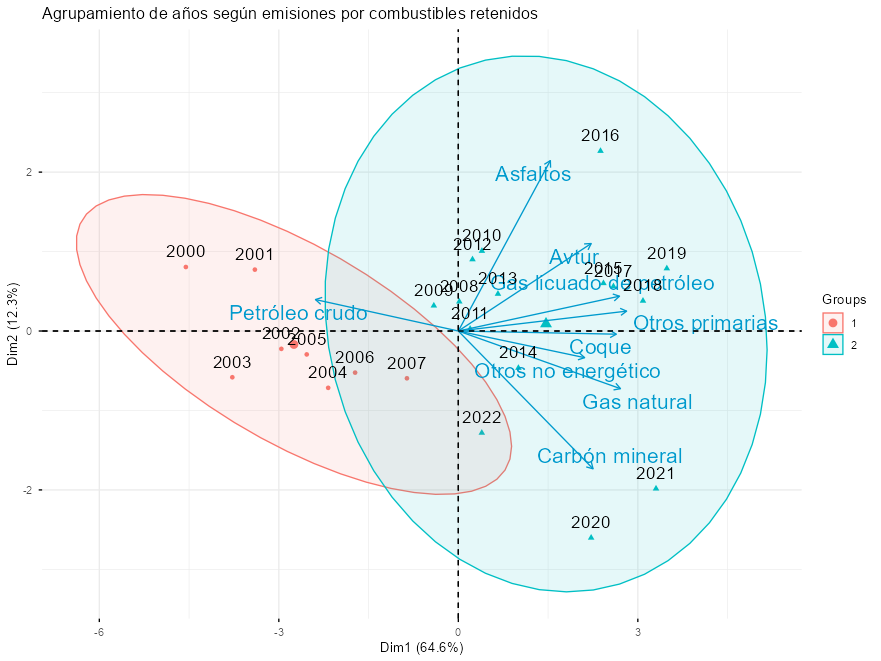

In [90]:
fviz_pca_biplot(
  pca,
  label = "var",
  geom.ind = "point",
  col.var = "#009ACD",
  habillage = as.factor(k2$cluster),
  addEllipses = TRUE,
  repel = TRUE,
  labelsize = 6,
  title = "Agrupamiento de años según emisiones por combustibles retenidos"
) +
  geom_text(
    aes(label = years),
    vjust = -0.8,
    size = 5,
    color = "black"
  )

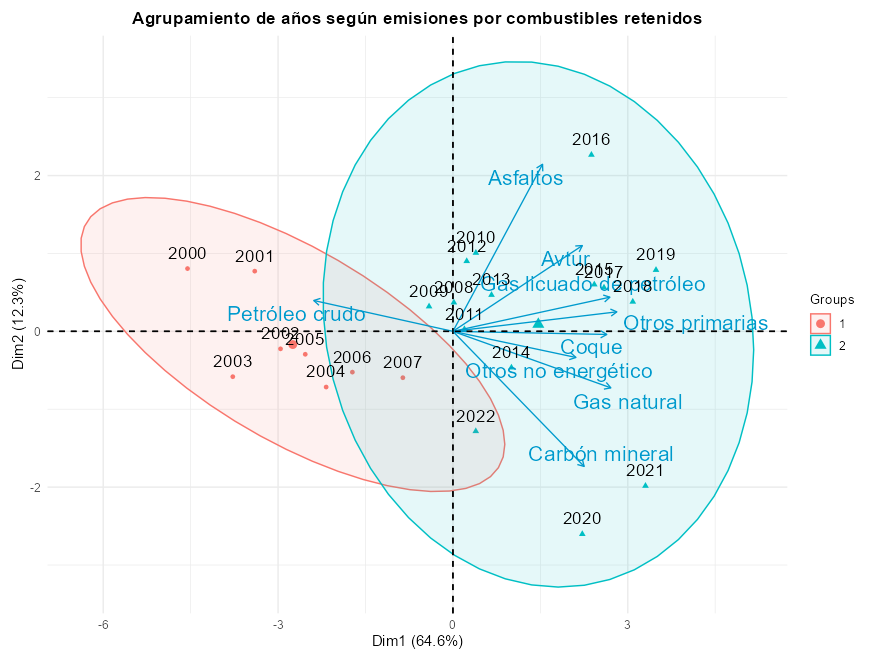

In [91]:
grafico_pca <- fviz_pca_biplot(
  pca,
  label = "var",
  geom.ind = "point",
  col.var = "#009ACD",
  habillage = as.factor(k2$cluster),
  addEllipses = TRUE,
  repel = TRUE,
  labelsize = 6,
  title = "Agrupamiento de años según emisiones por combustibles retenidos"
) +
  geom_text(
    aes(label = years),
    vjust = -0.8,
    size = 5,
    color = "black"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(
      hjust = 0.5,
      size = 14,
      face = "bold"
    ),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.text = element_text(size = 10),
    plot.margin = margin(10, 15, 10, 10)
  )

grafico_pca

In [92]:
ggsave(
  filename = paste0(
    "C:/Users/user/CO2-emsiones-tipo-combustible/",
    "results/figures/biplot_pca_agrupamiento.tiff"
  ),
  plot = grafico_pca,
  device = "tiff",
  width = 10,
  height = 8,
  units = "in",
  dpi = 600,
  compression = "lzw",
  bg = "white"
)

### Dendograma (using filtered dataset)

Warning message:
The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as of ggplot2 3.3.4.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <]8;;https://github.com/kassambara/factoextra/issueshttps://github.com/kassambara/factoextra/issues]8;;>.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 


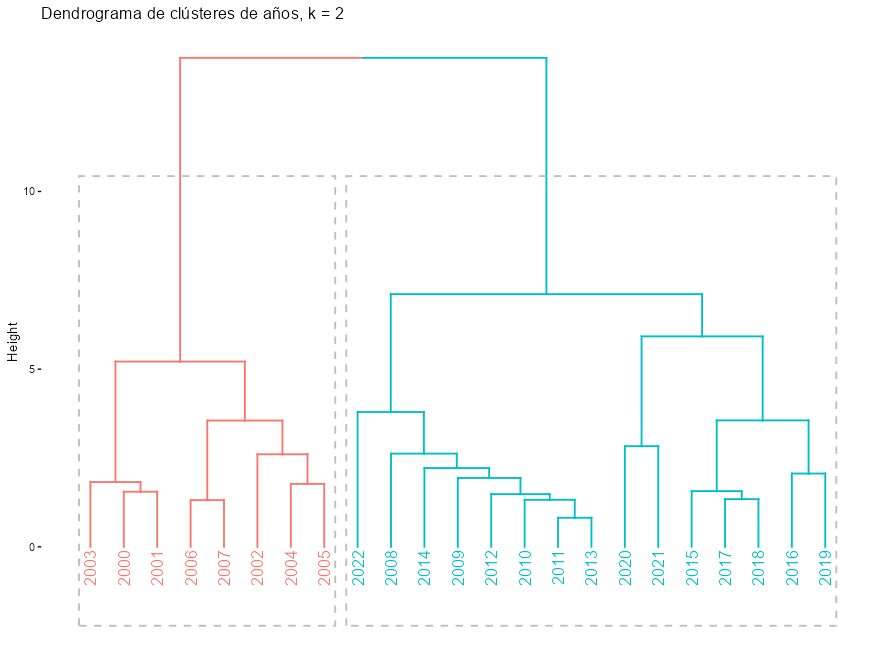

In [93]:
res2 <- hcut(X_cluster, k = 2, stand = FALSE)

fviz_dend(
  res2,
  cex = 0.9,
  k = 2,
  rect = TRUE,
  show_labels = TRUE
) +
  labs(title = "Dendrograma de clústeres de años, k = 2")

El análisis jerárquico (método de Ward) sobre la misma matriz estandarizada reproduce exactamente la misma partición en dos grupos que el k-means (ver Sección 7), a pesar de tratarse de algoritmos independientes con lógicas de agrupamiento distintas. Esta convergencia entre métodos constituye evidencia adicional de validez de la solución de dos clusters, más allá de los índices numéricos ya reportados.

#### perfiles de cluster

In [94]:
table(k2$cluster)


 1  2 
 8 15 

In [95]:
# --- Centroides en unidades originales (interpretables para el manuscrito) ---
perfil_original <- data_filtered_df[, -c(1, 2)] |>
  as.data.frame() |>
  mutate(Cluster = factor(k2$cluster)) |>
  group_by(Cluster) |>
  summarise(across(everything(), mean), n = n(), .groups = "drop") |>
  mutate(across(where(is.numeric) & !n, ~ round(.x, 1)))

perfil_original

# A tibble: 2 × 11
  Cluster Asfaltos Avtur `Carbón mineral` Coque `Gas licuado de petróleo` `Gas natural`
  <fct>      <dbl> <dbl>            <dbl> <dbl>                     <dbl>         <dbl>
1 1           44.7  544.            1720.  706.                     1646.          434.
2 2          104.   843.            3673. 1340.                     2396.         2334.
# ℹ 4 more variables: `Otros no energético` <dbl>, `Otros primarias` <dbl>,
#   `Petróleo crudo` <dbl>, n <int>

In [96]:
# --- Centroides estandarizados (z-scores; = k2$centers directamente, ya que
# X_cluster ya estaba escalado antes de correr kmeans) ---
perfil_z <- as.data.frame(k2$centers) |>
  mutate(Cluster = factor(seq_len(n()))) |>
  relocate(Cluster) |>
  mutate(across(where(is.numeric), ~ round(.x, 2)))

perfil_z

  Cluster Asfaltos Avtur Carbón mineral Coque Gas licuado de petróleo Gas natural
1       1    -0.81 -0.76          -0.72 -0.92                   -0.96       -1.09
2       2     0.43  0.41           0.38  0.49                    0.51        0.58
  Otros no energético Otros primarias Petróleo crudo
1               -0.66           -1.13           1.14
2                0.35            0.60          -0.61

In [97]:
# --- Tabla combinada lista para el manuscrito: Variable | Media_C1 | Media_C2 | Z_C1 | Z_C2 ---
medias_long <- perfil_original |>
  select(-n) |>
  pivot_longer(-Cluster, names_to = "Variable", values_to = "Media") |>
  pivot_wider(names_from = Cluster, values_from = Media, names_prefix = "Media_C")

z_long <- as.data.frame(k2$centers) |>
  mutate(Cluster = factor(seq_len(n()))) |>
  pivot_longer(-Cluster, names_to = "Variable", values_to = "Z") |>
  pivot_wider(names_from = Cluster, values_from = Z, names_prefix = "Z_C")

tabla_manuscrito <- medias_long |>
  left_join(z_long, by = "Variable") |>
  mutate(across(where(is.numeric), ~ round(.x, 2))) |>
  arrange(desc(abs(Z_C1 - Z_C2)))  # ordena por variable más discriminante entre clusters

tabla_manuscrito

# A tibble: 9 × 5
  Variable                Media_C1 Media_C2  Z_C1  Z_C2
  <chr>                      <dbl>    <dbl> <dbl> <dbl>
1 Petróleo crudo            6272.    3545.   1.14 -0.61
2 Otros primarias             27       34.7 -1.13  0.6 
3 Gas natural                434.    2334.  -1.09  0.58
4 Gas licuado de petróleo   1646.    2396.  -0.96  0.51
5 Coque                      706.    1340.  -0.92  0.49
6 Asfaltos                    44.7    104.  -0.81  0.43
7 Avtur                      544.     843.  -0.76  0.41
8 Carbón mineral            1720.    3673.  -0.72  0.38
9 Otros no energético         42.3     61   -0.66  0.35

#### Perfil visual (heatmap de z-scores por cluster)

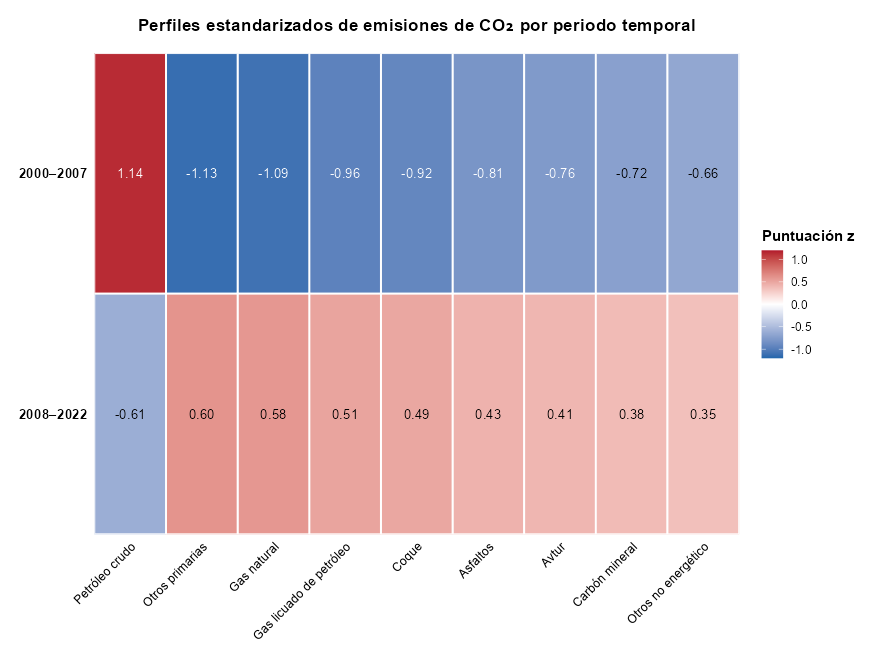

In [100]:
# ==========================================================
# FIGURA 3. Heatmap de perfiles estandarizados por periodo
# ==========================================================

# 1. Identificar automáticamente el periodo de cada clúster
periodos_cluster <- tibble(
  Año = years,
  Cluster = k2$cluster
) |>
  group_by(Cluster) |>
  summarise(
    Inicio = min(Año),
    Fin = max(Año),
    Periodo = paste0(Inicio, "\u2013", Fin),
    .groups = "drop"
  ) |>
  arrange(Inicio)

# Orden cronológico de los periodos
niveles_periodo <- periodos_cluster$Periodo

# 2. Ordenar variables según la diferencia absoluta
#    entre los centroides de ambos clústeres
orden_variables <- names(
  sort(
    abs(k2$centers[1, ] - k2$centers[2, ]),
    decreasing = TRUE
  )
)

# 3. Preparar los centroides estandarizados en formato largo
perfil_heatmap <- as.data.frame(k2$centers) |>
  mutate(Cluster = seq_len(n())) |>
  left_join(
    periodos_cluster |>
      select(Cluster, Periodo),
    by = "Cluster"
  ) |>
  pivot_longer(
    cols = -c(Cluster, Periodo),
    names_to = "Variable",
    values_to = "Z"
  ) |>
  mutate(
    Variable = factor(
      Variable,
      levels = orden_variables
    ),

    # Se invierte el orden para que el periodo inicial
    # aparezca en la parte superior del gráfico
    Periodo = factor(
      Periodo,
      levels = rev(niveles_periodo)
    )
  )

# 4. Establecer límites simétricos para la escala cromática
limite_z <- ceiling(
  max(abs(perfil_heatmap$Z)) * 10
) / 10

# 5. Construir la figura
figura3 <- ggplot(
  perfil_heatmap,
  aes(
    x = Variable,
    y = Periodo,
    fill = Z
  )
) +
  geom_tile(
    color = "white",
    linewidth = 0.7
  ) +

  # Texto blanco en las celdas más oscuras
  geom_text(
    aes(
      label = sprintf("%.2f", Z),
      color = abs(Z) >= 0.75
    ),
    size = 3.8
  ) +

  scale_color_manual(
    values = c(
      "FALSE" = "black",
      "TRUE" = "white"
    ),
    guide = "none"
  ) +

  scale_fill_gradient2(
    low = "#2166AC",
    mid = "white",
    high = "#B2182B",
    midpoint = 0,
    limits = c(-limite_z, limite_z),
    name = "Puntuación z"
  ) +

  scale_x_discrete(
    expand = c(0, 0)
  ) +

  scale_y_discrete(
    expand = c(0, 0)
  ) +

  labs(
    title = "Perfiles estandarizados de emisiones de CO\u2082 por periodo temporal",
    x = NULL,
    y = NULL
  ) +

  theme_minimal(base_size = 12) +

  theme(
    panel.grid = element_blank(),

    axis.text.x = element_text(
      angle = 45,
      hjust = 1,
      vjust = 1,
      size = 10,
      color = "black"
    ),

    axis.text.y = element_text(
      size = 11,
      face = "bold",
      color = "black"
    ),

    plot.title = element_text(
      size = 14,
      face = "bold",
      hjust = 0.5,
      margin = margin(b = 15)
    ),

    legend.title = element_text(
      face = "bold"
    ),

    plot.margin = margin(
      t = 15,
      r = 15,
      b = 15,
      l = 15
    )
  )

# Mostrar la figura
figura3

In [102]:
ggsave(
  filename = "C:/Users/user/CO2-emsiones-tipo-combustible/results/figures/Figura_3_heatmap_perfiles_estandarizados.tiff",
  plot = figura3,
  width = 10,
  height = 4.8,
  units = "in",
  dpi = 300,
  compression = "lzw",
  bg = "white"
)

In [103]:
# ==========================================================
# TABLA 3. Centroides originales y estandarizados por periodo
# ==========================================================

# Centroides en unidades originales
centroides_originales <- data_filtered_df[, -c(1, 2)] |>
  as.data.frame() |>
  mutate(
    Cluster = k2$cluster,
    Periodo = case_when(
      Cluster == periodos_cluster$Cluster[
        which.min(periodos_cluster$Inicio)
      ] ~ "2000–2007",

      TRUE ~ "2008–2022"
    )
  ) |>
  group_by(Periodo) |>
  summarise(
    across(where(is.numeric), mean),
    .groups = "drop"
  ) |>
  pivot_longer(
    cols = -Periodo,
    names_to = "Variable",
    values_to = "Media_original"
  )

# Centroides estandarizados
centroides_z <- as.data.frame(k2$centers) |>
  mutate(Cluster = seq_len(n())) |>
  left_join(
    periodos_cluster |>
      select(Cluster, Periodo),
    by = "Cluster"
  ) |>
  pivot_longer(
    cols = -c(Cluster, Periodo),
    names_to = "Variable",
    values_to = "Z"
  ) |>
  select(-Cluster)

# Combinar ambas escalas
tabla3 <- centroides_originales |>
  left_join(
    centroides_z,
    by = c("Periodo", "Variable")
  ) |>
  pivot_wider(
    names_from = Periodo,
    values_from = c(Media_original, Z)
  ) |>
  transmute(
    Combustible = Variable,
    `Media original 2000–2007` =
      `Media_original_2000–2007`,
    `z 2000–2007` =
      `Z_2000–2007`,
    `Media original 2008–2022` =
      `Media_original_2008–2022`,
    `z 2008–2022` =
      `Z_2008–2022`
  ) |>
  mutate(
    across(
      starts_with("Media"),
      ~ round(.x, 1)
    ),
    across(
      starts_with("z"),
      ~ round(.x, 2)
    )
  ) |>
  arrange(
    desc(
      abs(`z 2000–2007` - `z 2008–2022`)
    )
  )

tabla3

# A tibble: 10 × 5
   Combustible          Media original 2000–…¹ `z 2000–2007` Media original 2008–…² `z 2008–2022`
   <chr>                                 <dbl>         <dbl>                  <dbl>         <dbl>
 1 Petróleo crudo                       6272.           1.14                 3545.          -0.61
 2 Otros primarias                        27           -1.13                   34.7          0.6 
 3 Gas natural                           434.          -1.09                 2334.           0.58
 4 Gas licuado de petr…                 1646.          -0.96                 2396.           0.51
 5 Coque                                 706.          -0.92                 1340.           0.49
 6 Asfaltos                               44.7         -0.81                  104.           0.43
 7 Avtur                                 544.          -0.76                  843.           0.41
 8 Carbón mineral                       1720.          -0.72                 3673.           0.38
 

In [104]:
# ==========================================================
# GUARDAR TABLA 3
# ==========================================================

# Ruta de salida
table_dir <- "C:/Users/user/CO2-emsiones-tipo-combustible/results/tables"

# Crear la carpeta si no existe
dir.create(
  table_dir,
  recursive = TRUE,
  showWarnings = FALSE
)

# Instalar writexl si no está disponible
if (!requireNamespace("writexl", quietly = TRUE)) {
  install.packages("writexl")
}

# Guardar en formato Excel
writexl::write_xlsx(
  x = list(
    "Tabla 3" = tabla3
  ),
  path = file.path(
    table_dir,
    "Tabla_3_centroides_originales_estandarizados.xlsx"
  )
)

# Guardar también en formato CSV
readr::write_csv(
  tabla3,
  file = file.path(
    table_dir,
    "Tabla_3_centroides_originales_estandarizados.csv"
  ),
  na = ""
)

# Confirmar las rutas
cat(
  "Tabla Excel guardada en:\n",
  file.path(
    table_dir,
    "Tabla_3_centroides_originales_estandarizados.xlsx"
  ),
  "\n\nTabla CSV guardada en:\n",
  file.path(
    table_dir,
    "Tabla_3_centroides_originales_estandarizados.csv"
  ),
  "\n"
)

Tabla Excel guardada en:
 C:/Users/user/CO2-emsiones-tipo-combustible/results/tables/Tabla_3_centroides_originales_estandarizados.xlsx 

Tabla CSV guardada en:
 C:/Users/user/CO2-emsiones-tipo-combustible/results/tables/Tabla_3_centroides_originales_estandarizados.csv 


#### Listado explícito año → cluster

In [98]:
tabla_anio_cluster <- tibble(
  Año = years,
  Cluster = k2$cluster
) |>
  arrange(Año)

print(tabla_anio_cluster, n = Inf)

# A tibble: 23 × 2
     Año Cluster
   <dbl>   <int>
 1  2000       1
 2  2001       1
 3  2002       1
 4  2003       1
 5  2004       1
 6  2005       1
 7  2006       1
 8  2007       1
 9  2008       2
10  2009       2
11  2010       2
12  2011       2
13  2012       2
14  2013       2
15  2014       2
16  2015       2
17  2016       2
18  2017       2
19  2018       2
20  2019       2
21  2020       2
22  2021       2
23  2022       2


Cluster 1 (n = 8; años 2000–2007): perfil dominado por una alta dependencia del petróleo crudo (z = +1.14, el único valor positivo del cluster) y valores por debajo del promedio en las nueve fuentes restantes (z entre −0.66 y −1.13). El petróleo crudo promedia 6,272 unidades frente a 3,545 en el Cluster 2. Cluster 2 (n = 15; años 2008–2022): patrón inverso — petróleo crudo por debajo del promedio (z = −0.61) y todas las demás fuentes por encima (z entre +0.35 y +0.60), reflejando una matriz energética más diversificada (gas natural, GLP, coque, carbón mineral, asfaltos y avtur todos con mayor peso relativo). Las variables más discriminantes entre ambos clusters son, en orden: Petróleo crudo, Otros primarias y Gas natural — las tres con las mayores diferencias absolutas de z-score entre clusters. Esta bipartición coincide exactamente con la que arroja el análisis jerárquico de Ward (Sección 6) y con la dirección del PC1 (Sección 5), donde Petróleo crudo es la única variable con carga negativa. Tres métodos independientes — k-means, clustering jerárquico y la propia estructura del PC1 — convergen en la misma frontera temporal entre 2007 y 2008. La interpretación sustantiva de este quiebre (p. ej., vínculo con la incorporación de gas natural licuado a la matriz energética dominicana a mediados de la década de 2000) corresponde a la sección de Discusión del artículo principal, apoyada en literatura y fuentes del sector energético dominicano.